## Categorization of Cyber Security Attacks on IOT
by Andi (B.A.) Rodríguez Macuacé

In [1]:
#Importing project libraries
import os, time 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC



# 1. Descriptive Analysis of Data

In [2]:
# Importing dataset
attacks_data = pd.read_csv("../dataset/RT_IOT2022.csv", sep=",")

# Show data info
print("--- Basic Information ---")
print(attacks_data.info())
print("\n--- Basic Statistics ---")
print(attacks_data.describe())

row_count = len(attacks_data)
print("\n--- Total number of samples: ", row_count, "---")
print("--- Number of Attack data samples per Attack_type  ---")
original_counts = attacks_data.groupby('Attack_type').size()
print(original_counts)

--- Basic Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 85 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                123117 non-null  int64  
 1   id.orig_p                 123117 non-null  int64  
 2   id.resp_p                 123117 non-null  int64  
 3   proto                     123117 non-null  object 
 4   service                   123117 non-null  object 
 5   flow_duration             123117 non-null  float64
 6   fwd_pkts_tot              123117 non-null  int64  
 7   bwd_pkts_tot              123117 non-null  int64  
 8   fwd_data_pkts_tot         123117 non-null  int64  
 9   bwd_data_pkts_tot         123117 non-null  int64  
 10  fwd_pkts_per_sec          123117 non-null  float64
 11  bwd_pkts_per_sec          123117 non-null  float64
 12  flow_pkts_per_sec         123117 non-null  float64
 13  down_up_ratio     

In [3]:
#Checking for missing values
print("\n--- Missing Values ---")
print(attacks_data.isnull().sum())


--- Missing Values ---
Unnamed: 0              0
id.orig_p               0
id.resp_p               0
proto                   0
service                 0
                       ..
idle.std                0
fwd_init_window_size    0
bwd_init_window_size    0
fwd_last_window_size    0
Attack_type             0
Length: 85, dtype: int64


Add dataset link and description here

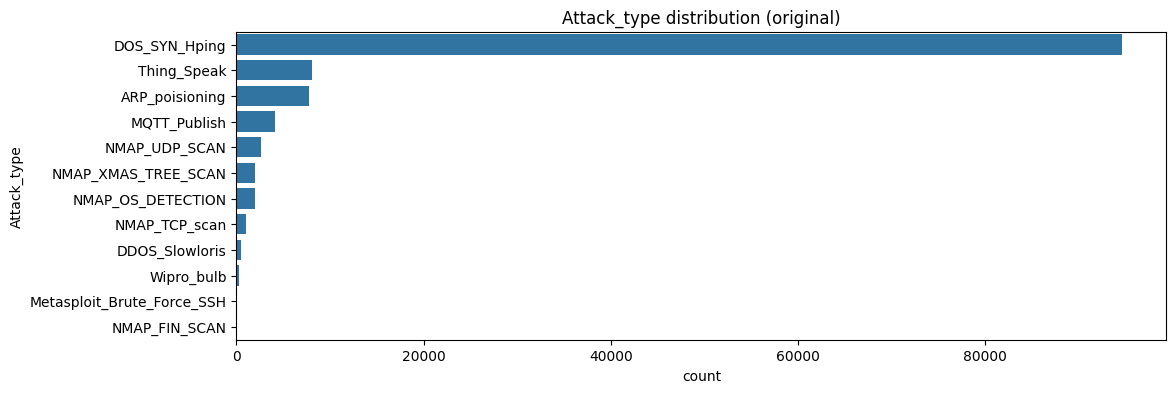

In [4]:
#Visualizing Initial Class distribution
plt.figure(figsize=(12,4))
sns.countplot(y='Attack_type', data=attacks_data, order=attacks_data['Attack_type'].value_counts().index)
plt.title("Attack_type distribution (original)")
plt.show()



--- Plotting Initial Feature Distributions ---


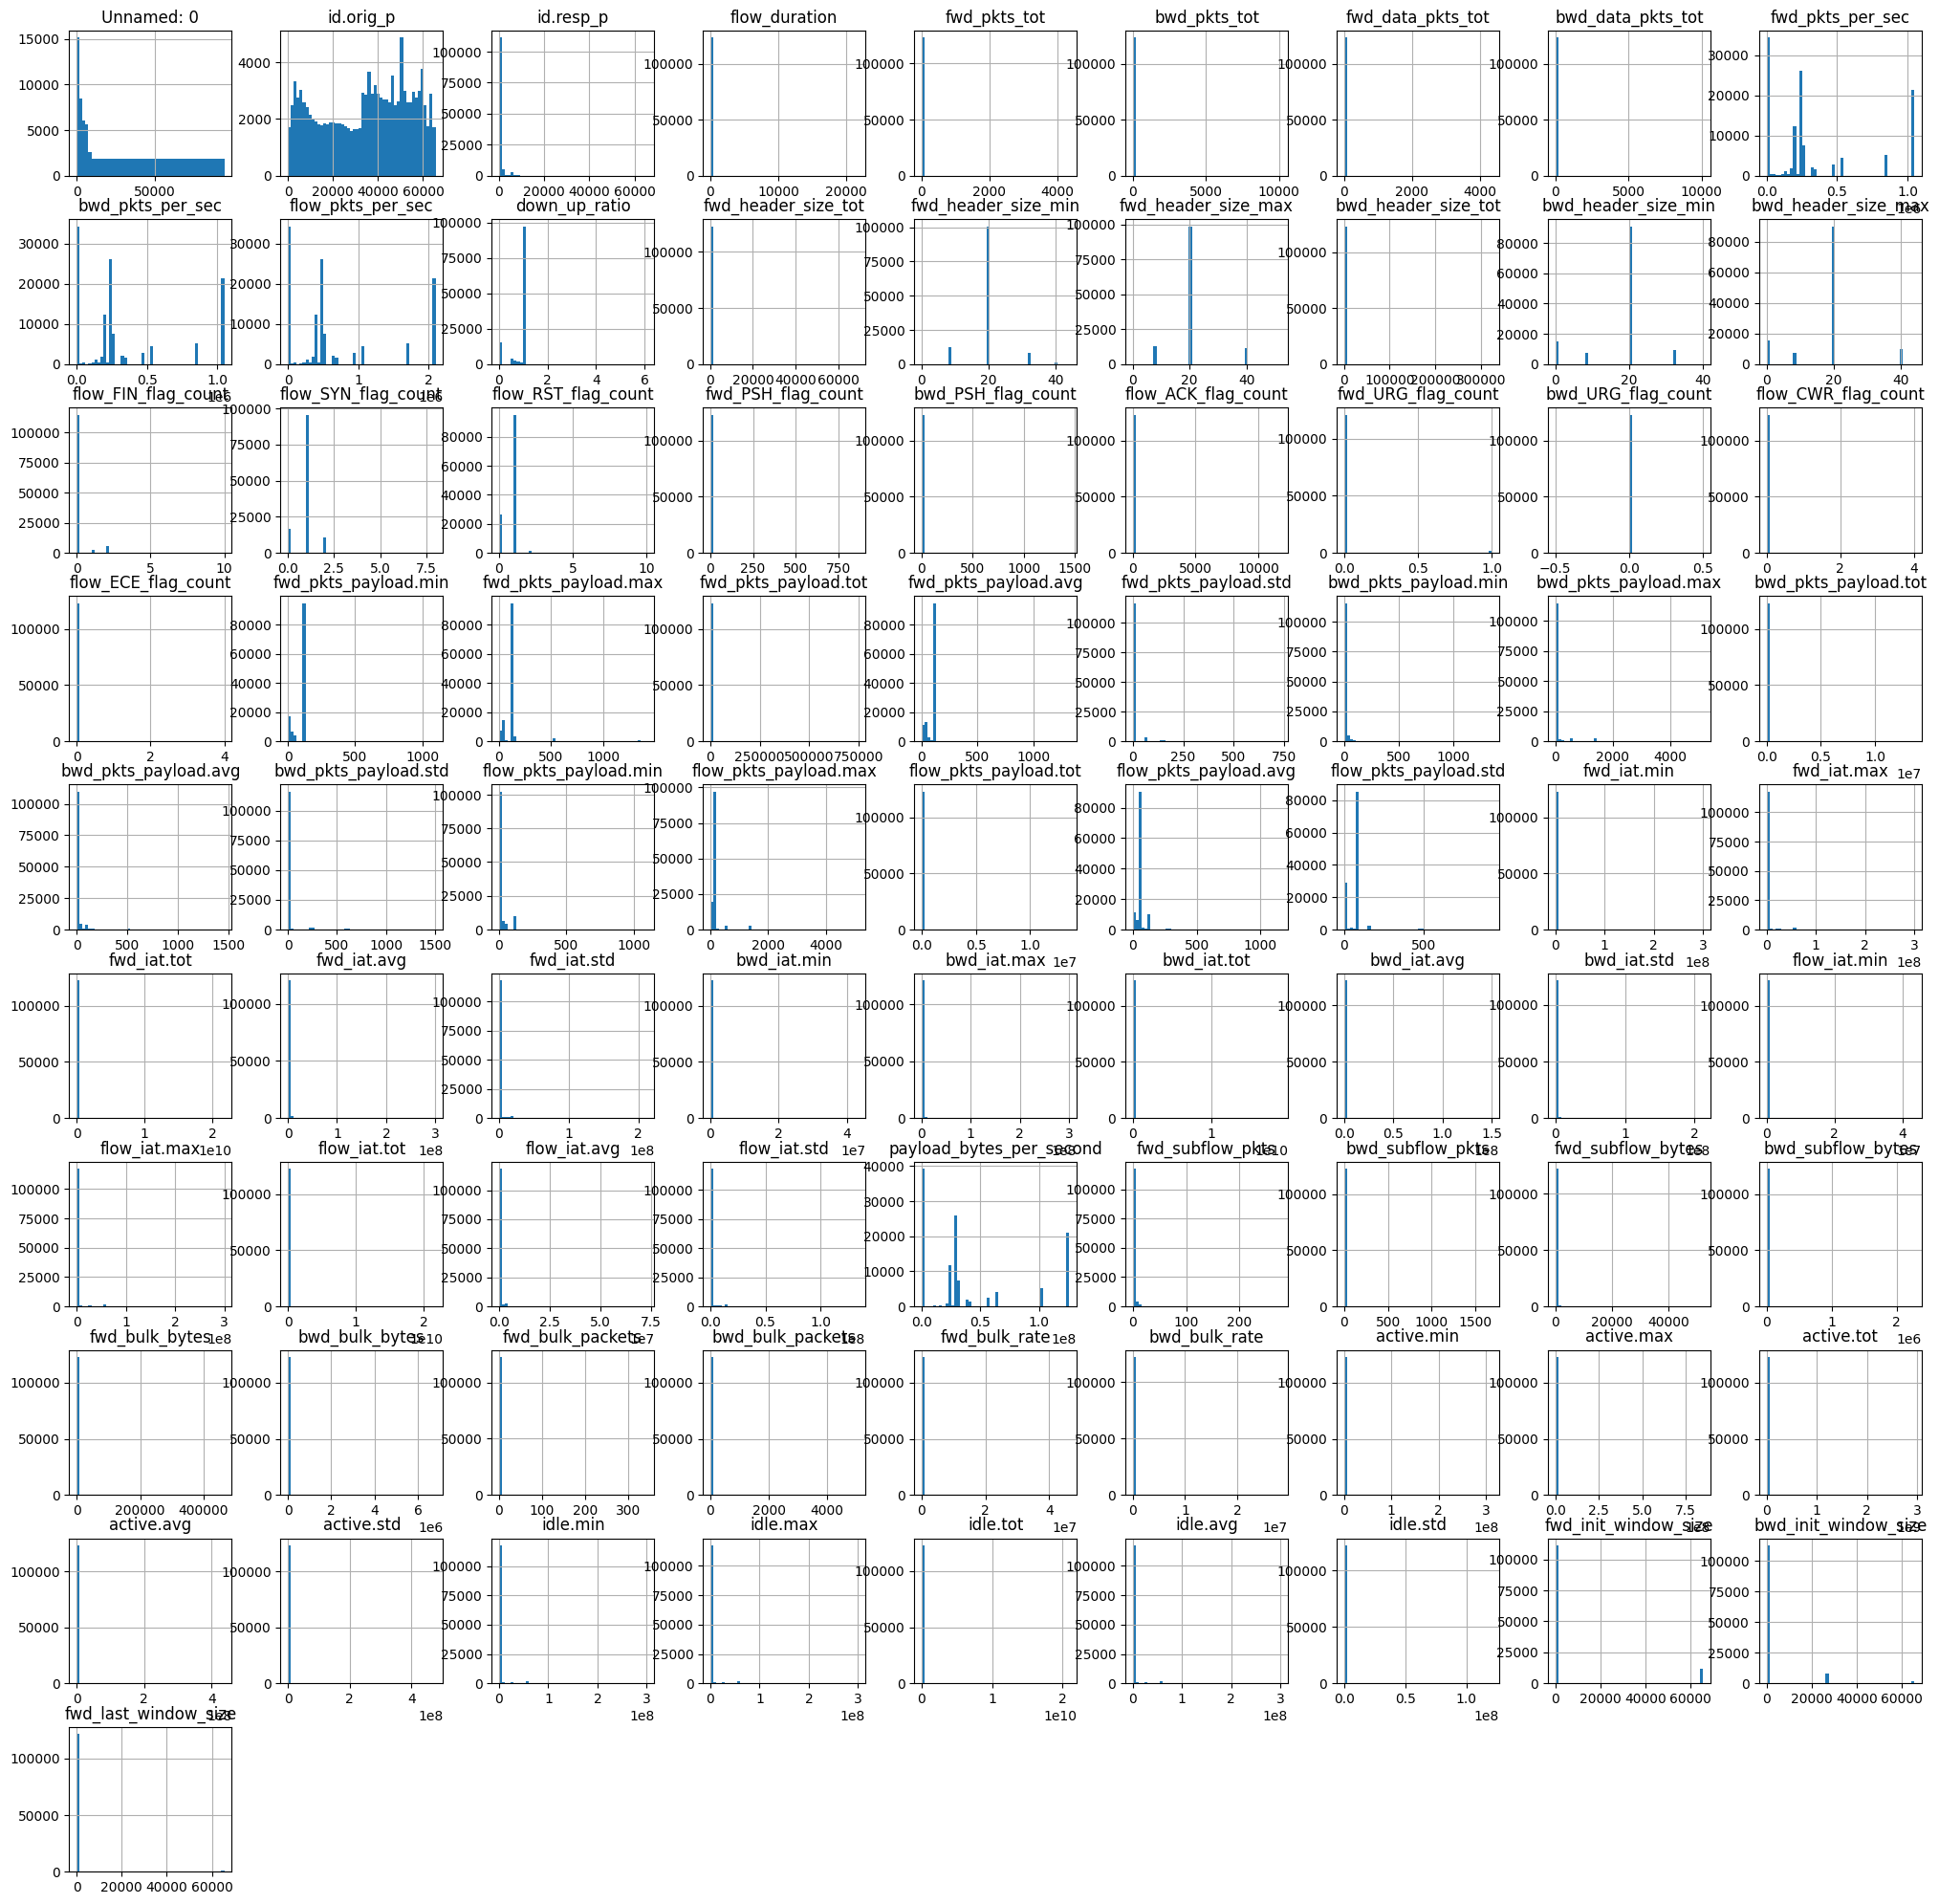

In [5]:
numeric_cols = attacks_data.select_dtypes(include=['int64', 'float64']).columns

#Visualizing Feature distribution histograms
print("\n--- Plotting Initial Feature Distributions ---")
attacks_data[numeric_cols].hist(bins=50, figsize=(25, 25))
plt.title("Raw Feature Distributions")
plt.show()


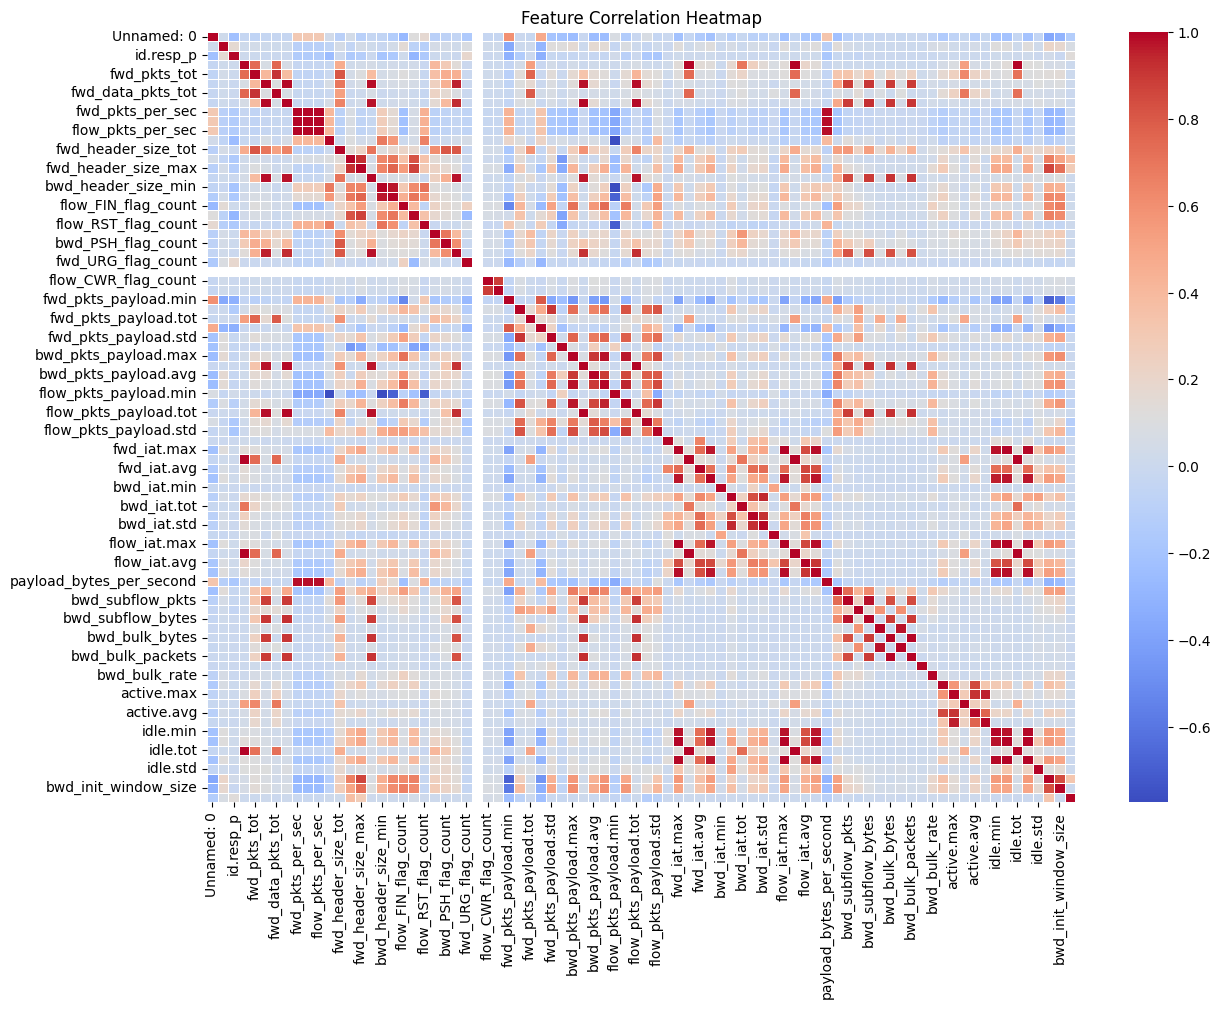

In [6]:
#Visualizing Feature Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(attacks_data[numeric_cols].corr(), cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Initial Visualization Results
The target distribution plot shows a very big imbalance in the dataset, where the attack type DOS-SYN flood has a total of 94.659 samples, which will most likely affect the accuracy of the model's prediction. This attack type should be removed from the dataset.

The feature distribution plot shows that most features are very right-skewed and heavily-tailed, with a big spike near zero and a long tail for bigger values, making the dataset not normally distributed. Scaling should be implemented when applying models like logistic regression.

The correlation heatmap of the features revealed several strongly correlated groups like the different packet payload statistics, inter-arrival-time statistics, and bulk transfer metrics. Keeping all of these redundant variables can introduce multicollinearity for linear models and unnecessarily increase dimensionality.


# 2. Implementation of necessary pre-processing

In [8]:
#Remove SYN flood attacks from dataset
filtered_attacks_data = attacks_data.loc[attacks_data['Attack_type'] != 'DOS_SYN_Hping']
filtered_row_count = len(filtered_attacks_data)
print("\n--- Attacks data samples without DOS_SYN_Hping: ",filtered_row_count, " ---")
filtered_counts = filtered_attacks_data.groupby('Attack_type').size()
print(filtered_counts)

#Remove ID column as it is not needed for analysis
filtered_attacks_data = filtered_attacks_data.drop(columns=['id.orig_p', 'id.resp_p'])



--- Attacks data samples without DOS_SYN_Hping:  28458  ---
Attack_type
ARP_poisioning                7750
DDOS_Slowloris                 534
MQTT_Publish                  4146
Metasploit_Brute_Force_SSH      37
NMAP_FIN_SCAN                   28
NMAP_OS_DETECTION             2000
NMAP_TCP_scan                 1002
NMAP_UDP_SCAN                 2590
NMAP_XMAS_TREE_SCAN           2010
Thing_Speak                   8108
Wipro_bulb                     253
dtype: int64


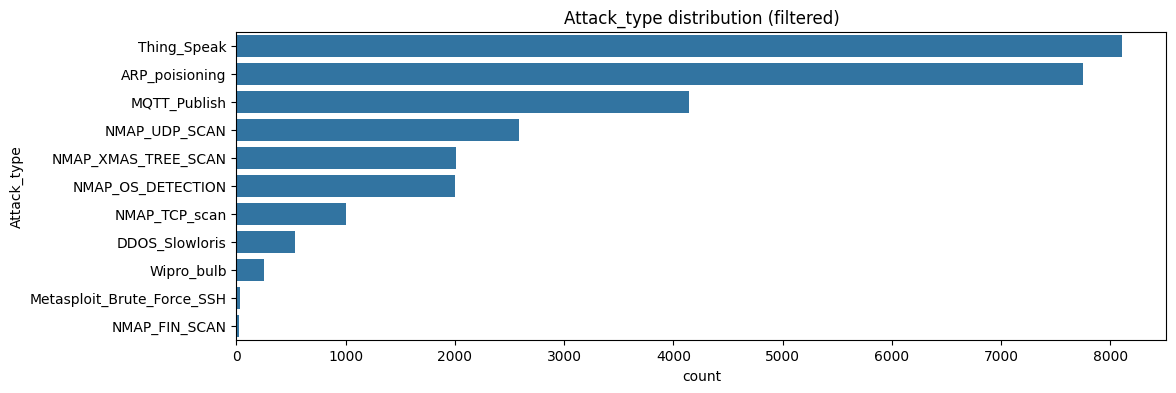

In [9]:
# Visualization of New target Distribution (Attack type)
plt.figure(figsize=(12,4))
sns.countplot(y='Attack_type', data=filtered_attacks_data, order=filtered_attacks_data['Attack_type'].value_counts().index)
plt.title("Attack_type distribution (filtered)")
plt.show()

In [10]:
#Separating Features and Target
X = filtered_attacks_data.drop('Attack_type', axis=1)
y = filtered_attacks_data['Attack_type']

#correlation prunning of features
corr = X.select_dtypes(include=[np.number]).corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

#drop features with any correlation > 0.95
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print("Dropping", len(to_drop), "highly correlated features")
X_reduced = X.drop(columns=to_drop)

# Show reduced data features
print("---Reduced Features---")
print(X_reduced.info())

Dropping 26 highly correlated features
---Reduced Features---
<class 'pandas.core.frame.DataFrame'>
Index: 28458 entries, 0 to 123116
Data columns (total 56 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                28458 non-null  int64  
 1   proto                     28458 non-null  object 
 2   service                   28458 non-null  object 
 3   flow_duration             28458 non-null  float64
 4   fwd_pkts_tot              28458 non-null  int64  
 5   bwd_pkts_tot              28458 non-null  int64  
 6   fwd_data_pkts_tot         28458 non-null  int64  
 7   fwd_pkts_per_sec          28458 non-null  float64
 8   down_up_ratio             28458 non-null  float64
 9   fwd_header_size_tot       28458 non-null  int64  
 10  fwd_header_size_min       28458 non-null  int64  
 11  fwd_header_size_max       28458 non-null  int64  
 12  bwd_header_size_min       28458 non-null  int64  
 13  flo

In [ ]:
# function for encoding all text-based features and target
def labelEncodingFunction(X, y):
    label_encoders = {}
    for column in X.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X[column] = le.fit_transform(X[column])
        label_encoders[column] = le
    le_target = LabelEncoder()
    y_encoded = le_target.fit_transform(y)
    return X, y_encoded, label_encoders

X, y_encoded, label_encoders = labelEncodingFunction(X_reduced, y)


Explain preprocessing decisions

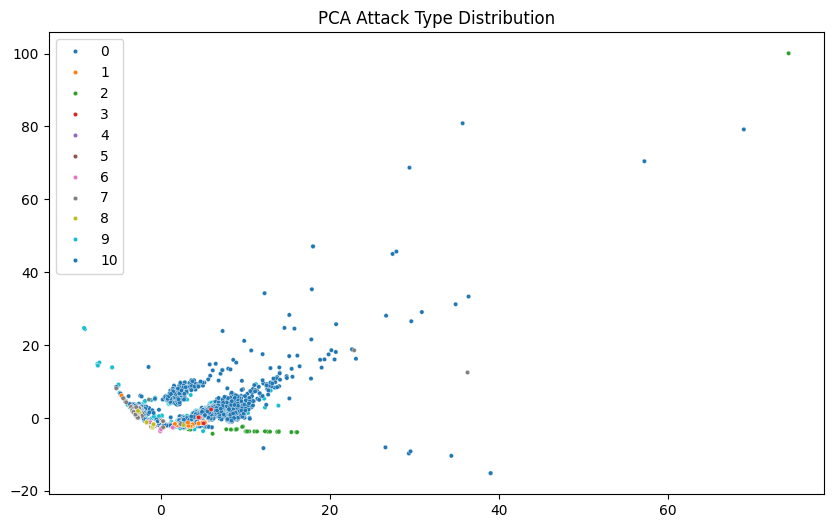

In [12]:
# perform a PCA in the dataset to see distribution of the different types.
# Scale full dataset for PCA
scaler_pca = StandardScaler()
X_scaled_for_pca = scaler_pca.fit_transform(X)

pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_scaled_for_pca)

plt.figure(figsize=(10,6))
sns.scatterplot(
    x=X_pca_2d[:,0],
    y=X_pca_2d[:,1],
    hue=y_encoded,
    palette="tab10",
    s=10
)
plt.title("PCA Attack Type Distribution")
plt.show()

Explain why the PCA and what the visualization shows.

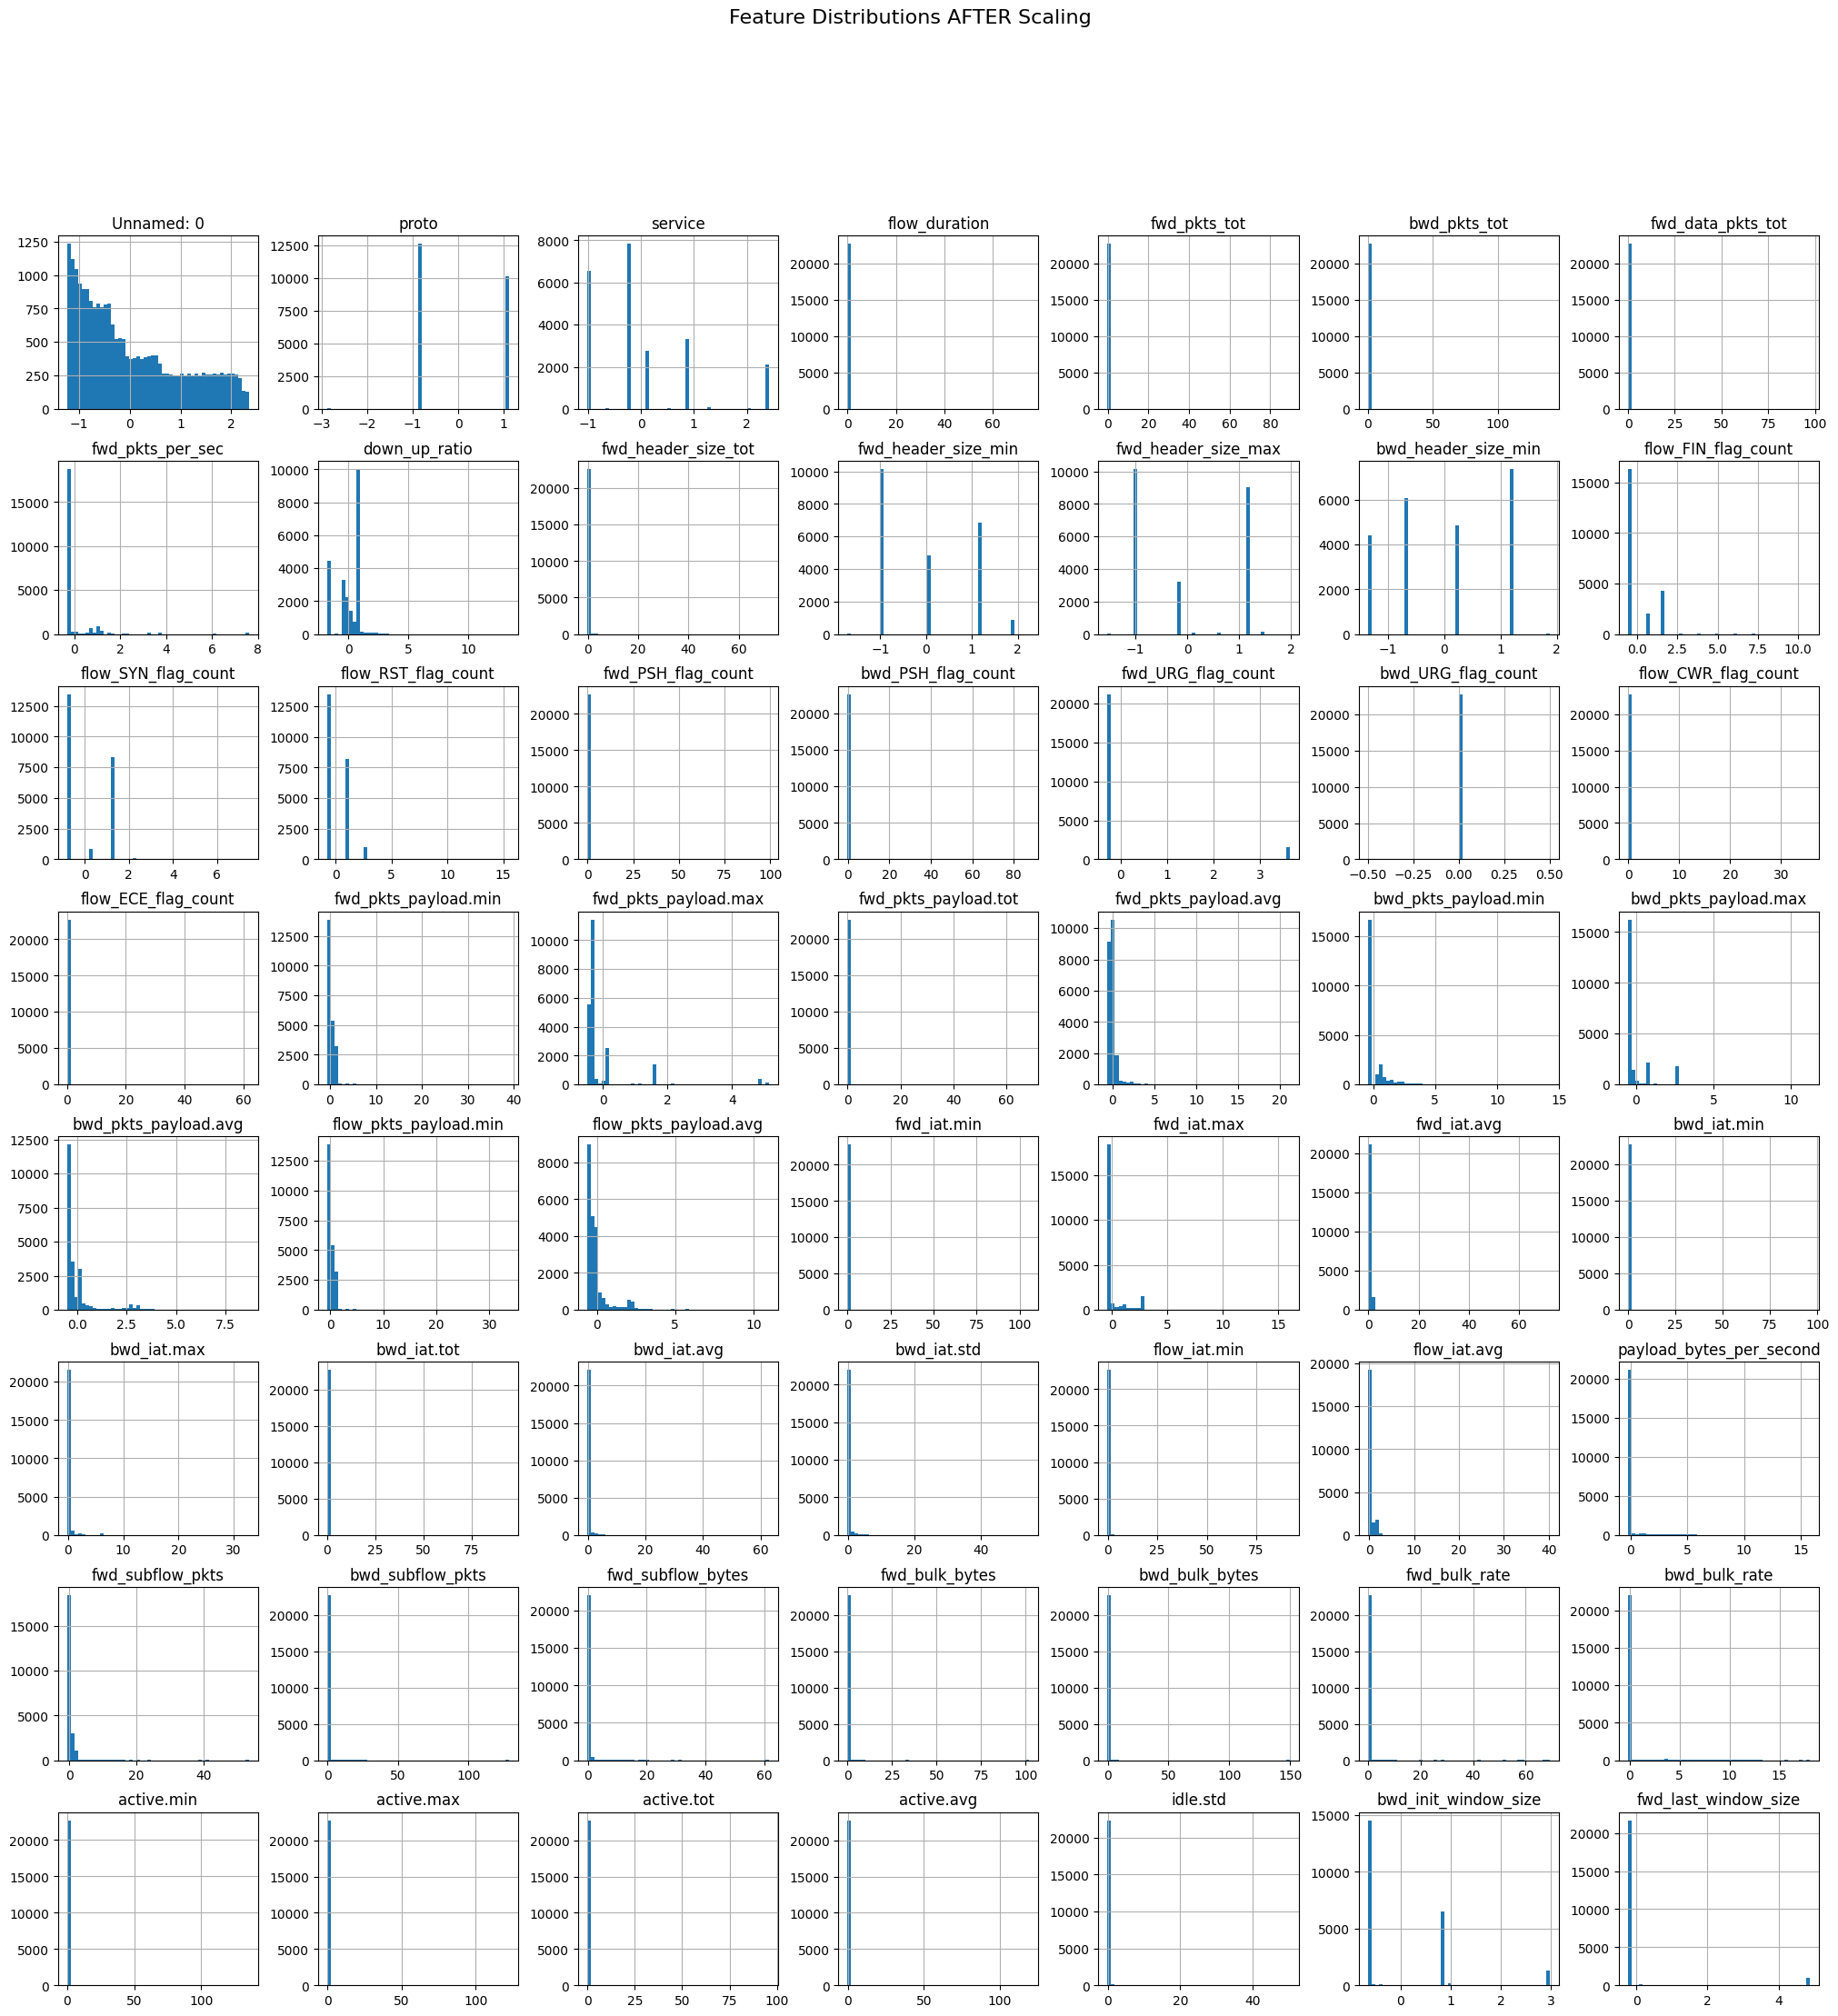

In [13]:
#Split dataset into test and train sets for X and y with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

#Scale the data for feature range normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Visualizing feature distributions after scaling
scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

scaled_df.hist(figsize=(25,25), bins=50)
plt.suptitle("Feature Distributions AFTER Scaling", fontsize=16)
plt.show()

In [14]:
#Using SMote to balance the dataset
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

#class distribution before and after SMOTE
print("Class distribution before SMOTE:", Counter(y_train))
print("Class distribution after SMOTE:", Counter(y_train_balanced))

Class distribution before SMOTE: Counter({np.int64(9): 6486, np.int64(0): 6200, np.int64(2): 3317, np.int64(7): 2072, np.int64(8): 1608, np.int64(5): 1600, np.int64(6): 802, np.int64(1): 427, np.int64(10): 202, np.int64(3): 30, np.int64(4): 22})
Class distribution after SMOTE: Counter({np.int64(6): 6486, np.int64(9): 6486, np.int64(0): 6486, np.int64(7): 6486, np.int64(5): 6486, np.int64(2): 6486, np.int64(1): 6486, np.int64(8): 6486, np.int64(3): 6486, np.int64(10): 6486, np.int64(4): 6486})


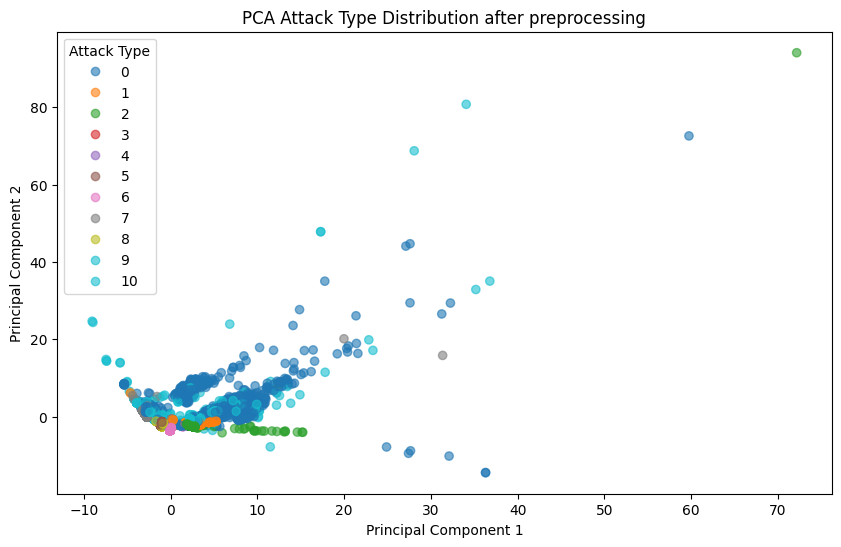

In [15]:
# performing a PCA in the balanced/scaled dataset to see distribution of the different types after preprocessing
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(10,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, cmap='tab10', alpha=0.6)
plt.title("PCA Attack Type Distribution after preprocessing")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(*scatter.legend_elements(), title="Attack Type")
plt.show()

Explain reasons for scaling and other pre-processing decions, as well as describe what is seen in the figure

# 4. Selection of baseline model
Because the problem at hand focuses on (multiclass) classification tasks, the baseline model will be Logistic Regression as it is fast, easy to interpret and overall has a good reputation of performance for this type of cases.

In [ ]:
#Initializing Logistic Regression Model as baseline model
baseline_model = LogisticRegression(max_iter=1000, random_state=42)

#training baseline model
baseline_model.fit(X_train_balanced, y_train_balanced)

#Making prediction
y_prediction = baseline_model.predict(X_test_scaled)
y_probability = baseline_model.predict_proba(X_test_scaled)

#Displaying baseline model performance
print("Classification Report: \n", classification_report(y_test, y_prediction))

print("\nAccuracy: ", accuracy_score(y_test, y_prediction))
print("\nF1-score: ", f1_score(y_test, y_prediction, average='weighted'))
print("\nROC-AUC: ", roc_auc_score(y_test, y_probability, multi_class='ovr'))
print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_prediction))


Classification Report: 
               precision    recall  f1-score   support

           0       0.95      0.90      0.93      1550
           1       0.80      0.95      0.87       107
           2       1.00      1.00      1.00       829
           3       0.20      0.86      0.32         7
           4       0.42      0.83      0.56         6
           5       1.00      1.00      1.00       400
           6       0.99      0.99      0.99       200
           7       0.95      0.95      0.95       518
           8       1.00      1.00      1.00       402
           9       0.93      0.94      0.93      1622
          10       0.74      0.98      0.84        51

    accuracy                           0.95      5692
   macro avg       0.82      0.95      0.85      5692
weighted avg       0.95      0.95      0.95      5692


Accuracy:  0.9481728742094168

F1-score:  0.9498130419922973

ROC-AUC:  0.9925825951709182

=== Confusion Matrix ===
[[1400    2    2    6    4    0    1    3   

# Base model results
The overall accuracy and F1 score are decent, sitting at arround 0.95 each, the ROC-AUC score is of 0.995 with a very strong separability, however upon further reading of the metrics, the data demonstrates to still be veyr unbalanced with a very good precission for classes with lots of samples, and incredible low precision and F1 for small classes (0.22 for class 3 and 0.42 for class 4). It can also be seen in the confusion matrix that some large classes migth be misclassified and confused for different classes, indicating a possible overlap in feature space. In order to fix this issues, imbalance in small classes should be addressed and when using different models and evaluation of classes and their priority (as well as some error analysis should be done.)

<Figure size 1000x600 with 0 Axes>

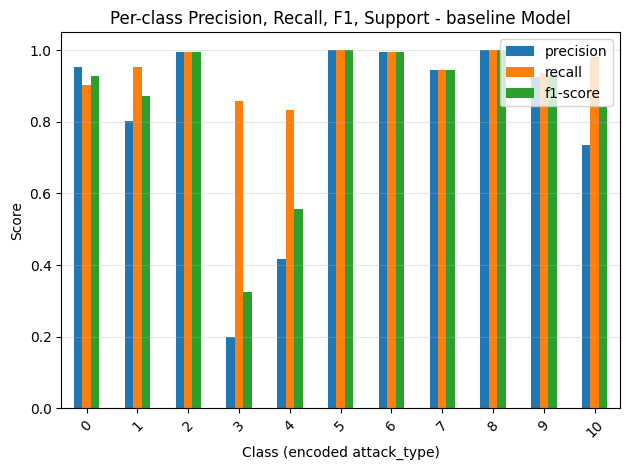

In [51]:
# function for visualizing Precision, Recall, F1 per class for all models
def visualize_class_metrics(report_df):
    class_metrics = report_df.iloc[:-3][['precision', 'recall', 'f1-score']]

    plt.figure(figsize=(10,6))
    class_metrics.plot(kind='bar')
    plt.title("Per-class Precision, Recall, F1, Support - baseline Model")
    plt.xlabel("Class (encoded attack_type)")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Visualizing Precision, Recall, F1 per class
base_report = classification_report(y_test, y_prediction, output_dict=True)
base_report_df = pd.DataFrame(base_report).transpose()
visualize_class_metrics(base_report_df)

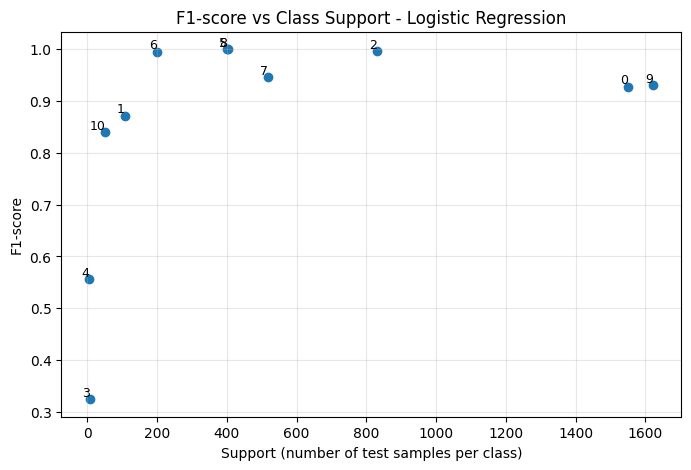

In [56]:
# function for visualizing F1-score vs Support per class for all models
def visualize_f1_vs_support(report_df):
    class_rows = report_df.iloc[:-3]
    f1_scores = class_rows['f1-score']
    supports = class_rows['support']

    plt.figure(figsize=(8,5))
    plt.scatter(supports, f1_scores)
    for cls, x, y in zip(class_rows.index, supports, f1_scores):
        plt.text(x, y, str(cls), fontsize=9, ha='right', va='bottom')

    plt.xlabel("Support (number of test samples per class)")
    plt.ylabel("F1-score")
    plt.title("F1-score vs Class Support - Logistic Regression")
    plt.grid(alpha=0.3)
    plt.show()

#visualizing F1-score vs Support per class for baseline model
visualize_f1_vs_support(base_report_df)

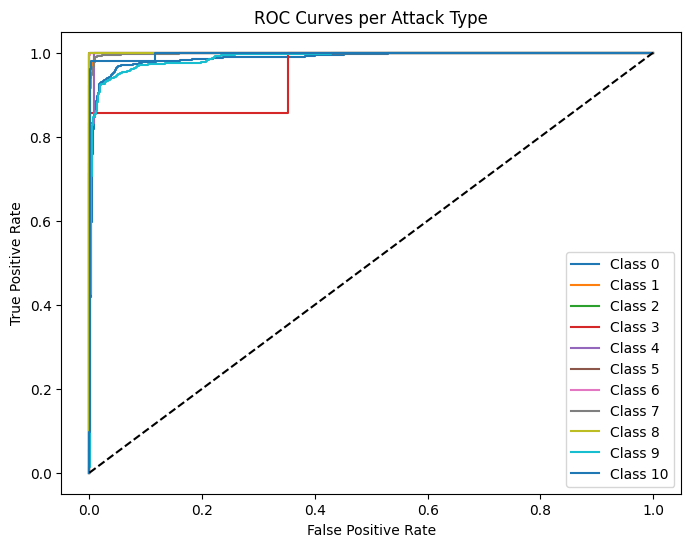

In [46]:
def plot_roc_curves(test_data, probability_data):
    y_test_bin = label_binarize(test_data, classes=np.unique(y_test))
    n_classes = y_test_bin.shape[1]

    plt.figure(figsize=(8,6))

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probability_data[:, i])
        plt.plot(fpr, tpr, label=f"Class {i}")

    plt.plot([0,1],[0,1],'k--')
    plt.title("ROC Curves per Attack Type")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

# Visualizing ROC curve for each class in baseline model
plot_roc_curves(y_test, y_probability)

explain briefly what is shown in the figures

explainn what this figure represents

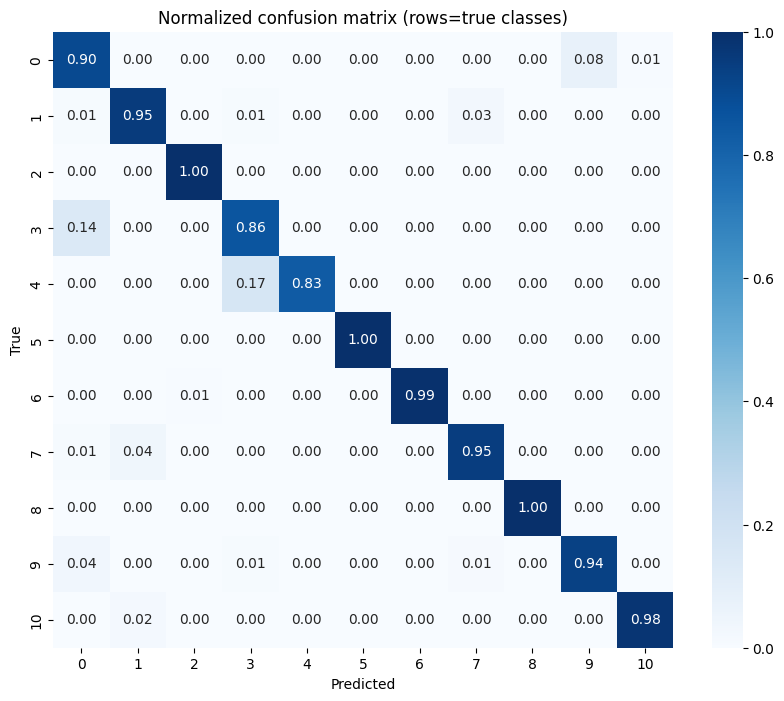

In [42]:
# Function to plot confusion matrix for all models dynamically
def plot_confusion_matrix(test_data, prediction_data):
    cm = confusion_matrix(test_data, prediction_data)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(10,8))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues')
    plt.title("Normalized confusion matrix (rows=true classes)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

#visualize confusion matrix for baseline model
plot_confusion_matrix(y_test, y_prediction)

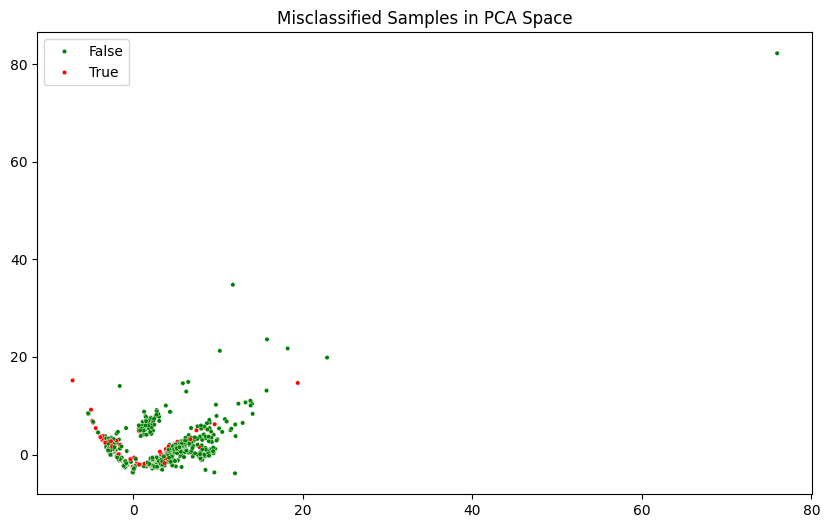

In [ ]:
#showing misclassified samples in PCA after prediction with baseline model
X_test_pca = pca.transform(X_test_scaled)

plt.figure(figsize=(10,6))
sns.scatterplot(x=X_test_pca[:,0], y=X_test_pca[:,1],
                hue=(y_test != y_prediction),
                palette={True:"red", False:"green"}, s=10)
plt.title("Misclassified Samples in PCA Space")
plt.show()

In [23]:
#Applying GridSearchCV to Logistic Regression
param_grid_lr = {
    'C': [0.1, 1, 5, 10],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [200, 500, 1000]
}

grid_lr = GridSearchCV(LogisticRegression(random_state=42),
                       param_grid_lr,
                       cv=3,
                       scoring='f1_weighted',
                       n_jobs=-1)

grid_lr.fit(X_train_scaled, y_train)

#displaying results of hyperparameters tuning with GridSearchCV for Logistic Regression
print("Best LR params:", grid_lr.best_params_)

Best LR params: {'C': 10, 'max_iter': 500, 'solver': 'lbfgs'}


### Results of Hyperparameter tuning with GridSearchCV

# 5. Implementation of Advance Models
The chosen advanced models that will be compared against the baseline model are Random Forest, as it is a very stron nonlinear classifier and handles imbalanced classes better than Logistic Regresion; and SVM which is good for PCA-like boundares and scaled data.

In [ ]:
# Training Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)

# Displaying Random Forest performance
print("\n--- Random Forest Performance ---")
print(classification_report(y_test, rf_pred))
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("F1-score:", f1_score(y_test, rf_pred, average='weighted'))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba, multi_class='ovr'))


--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1550
           1       0.95      0.94      0.95       107
           2       1.00      1.00      1.00       829
           3       1.00      0.86      0.92         7
           4       1.00      0.83      0.91         6
           5       1.00      1.00      1.00       400
           6       1.00      1.00      1.00       200
           7       0.98      0.99      0.99       518
           8       1.00      1.00      1.00       402
           9       0.99      0.99      0.99      1622
          10       0.98      0.98      0.98        51

    accuracy                           0.99      5692
   macro avg       0.99      0.96      0.98      5692
weighted avg       0.99      0.99      0.99      5692

Accuracy: 0.9926212227687983
F1-score: 0.992607197911007
ROC-AUC: 0.9921593928217991


<Figure size 1000x600 with 0 Axes>

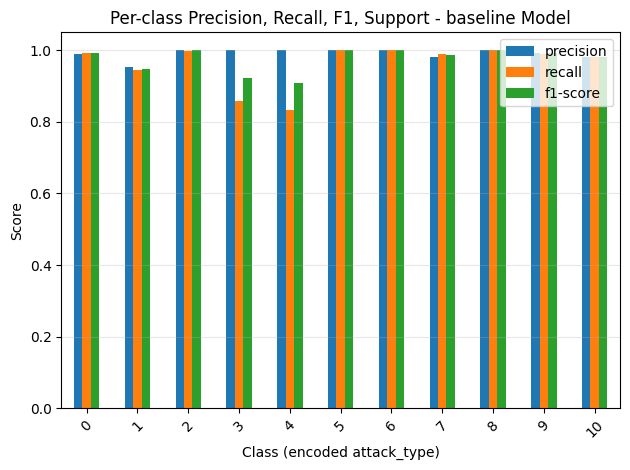

In [52]:
#Visualizing Precision, Recall, F1 per class for Random Forest model
rf_report = classification_report(y_test, rf_pred, output_dict=True)
rf_report_df = pd.DataFrame(rf_report).transpose()
visualize_class_metrics(rf_report_df)

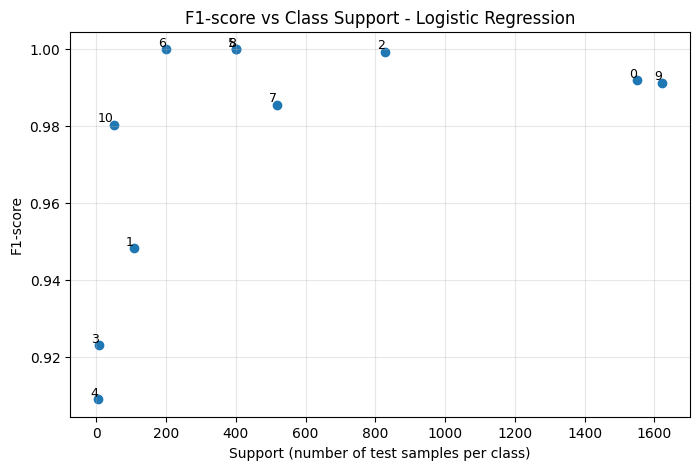

In [57]:
#visualizing F1-score vs Support per class for Random Forest model
visualize_f1_vs_support(rf_report_df)

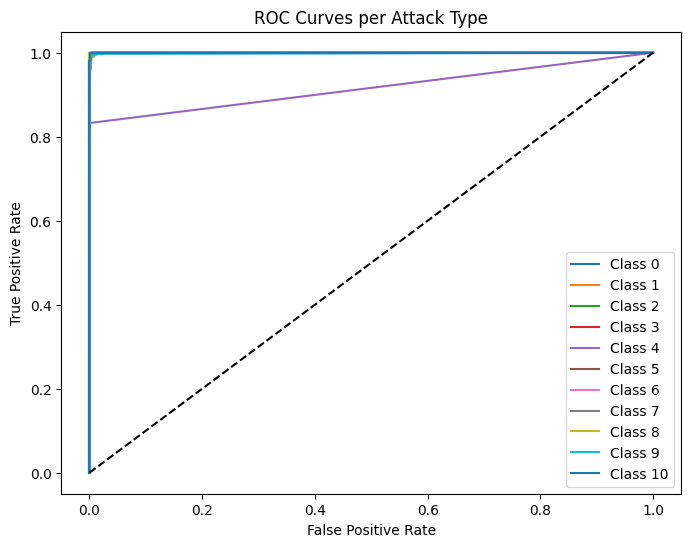

In [ ]:
# Visualizing ROC curve for each class in Random Forest model
plot_roc_curves(y_test, rf_proba)

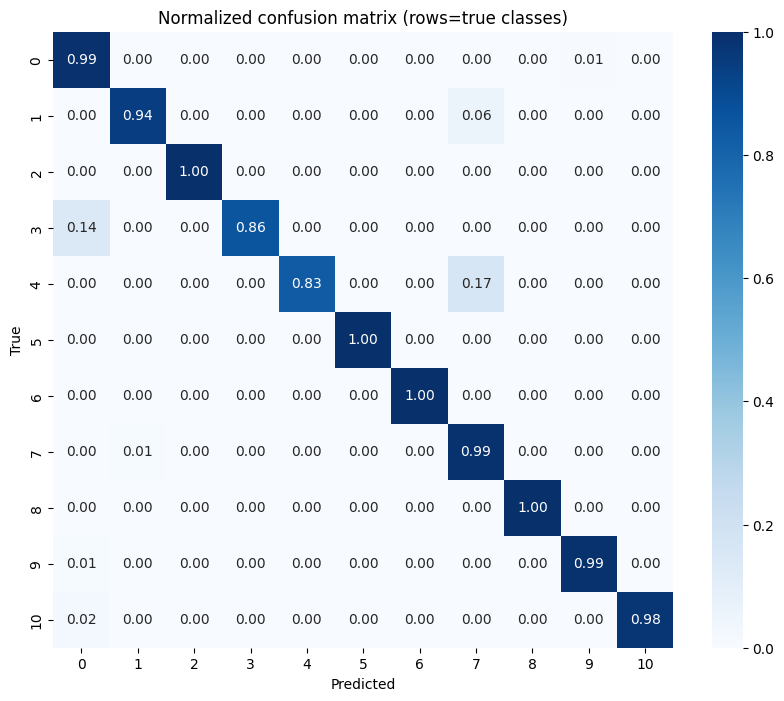

In [43]:
# Visualizing Random Forest Confusion Matrix
plot_confusion_matrix(y_test, rf_pred)

In [25]:
# Training SVM model
svm_model = SVC(
    C=10,
    kernel='rbf',
    gamma='scale',
    probability=True,
    class_weight='balanced',
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_proba = svm_model.predict_proba(X_test_scaled)

# Displaying SVM performance
print("\n--- SVM Performance ---")
print(classification_report(y_test, svm_pred))
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("F1-score:", f1_score(y_test, svm_pred, average='weighted'))
print("ROC-AUC:", roc_auc_score(y_test, svm_proba, multi_class='ovr'))


--- SVM Performance ---
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1550
           1       0.82      0.96      0.89       107
           2       1.00      1.00      1.00       829
           3       0.30      0.86      0.44         7
           4       0.40      1.00      0.57         6
           5       1.00      1.00      1.00       400
           6       1.00      1.00      1.00       200
           7       0.97      0.96      0.97       518
           8       1.00      1.00      1.00       402
           9       0.99      0.96      0.97      1622
          10       0.94      0.94      0.94        51

    accuracy                           0.98      5692
   macro avg       0.85      0.97      0.89      5692
weighted avg       0.98      0.98      0.98      5692

Accuracy: 0.9764581869290232
F1-score: 0.9775154960848769
ROC-AUC: 0.9984022345972711


<Figure size 1000x600 with 0 Axes>

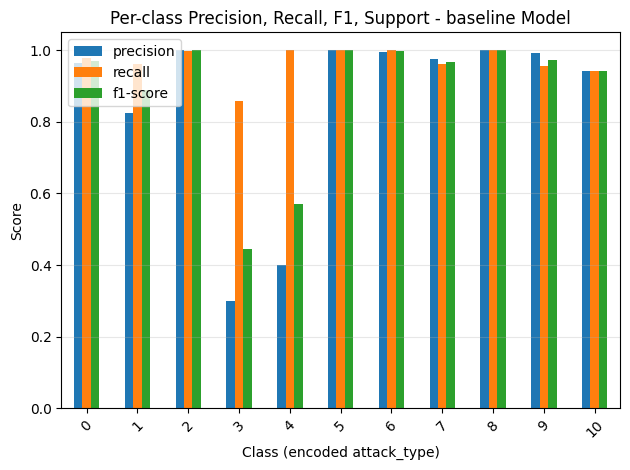

In [53]:
#Visualizing Precision, Recall, F1 per class for SVM model
svm_report = classification_report(y_test, svm_pred, output_dict=True)
svm_report_df = pd.DataFrame(svm_report).transpose()
visualize_class_metrics(svm_report_df)

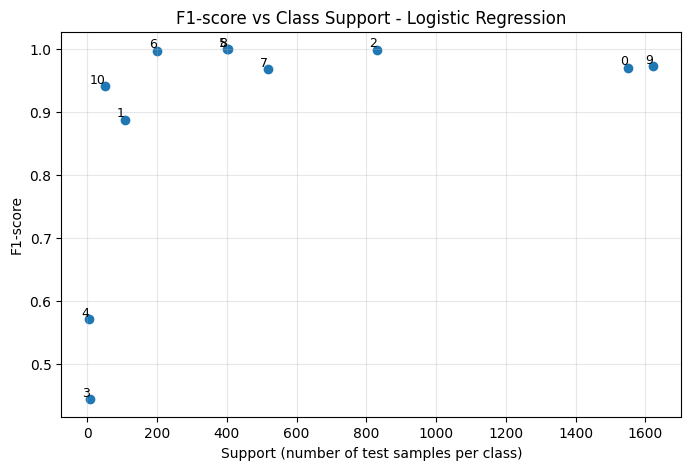

In [58]:
#visualizing F1-score vs Support per class for SVM model
visualize_f1_vs_support(svm_report_df)

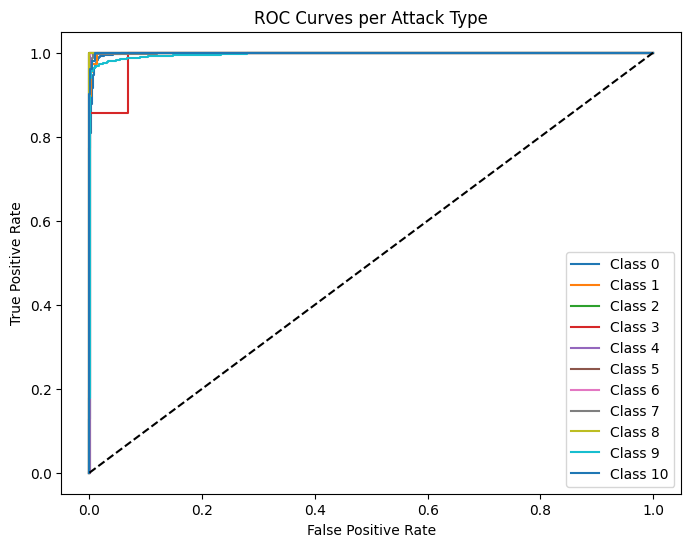

In [48]:
# Visualizing ROC curve for each class in SVM model
plot_roc_curves(y_test, svm_proba)

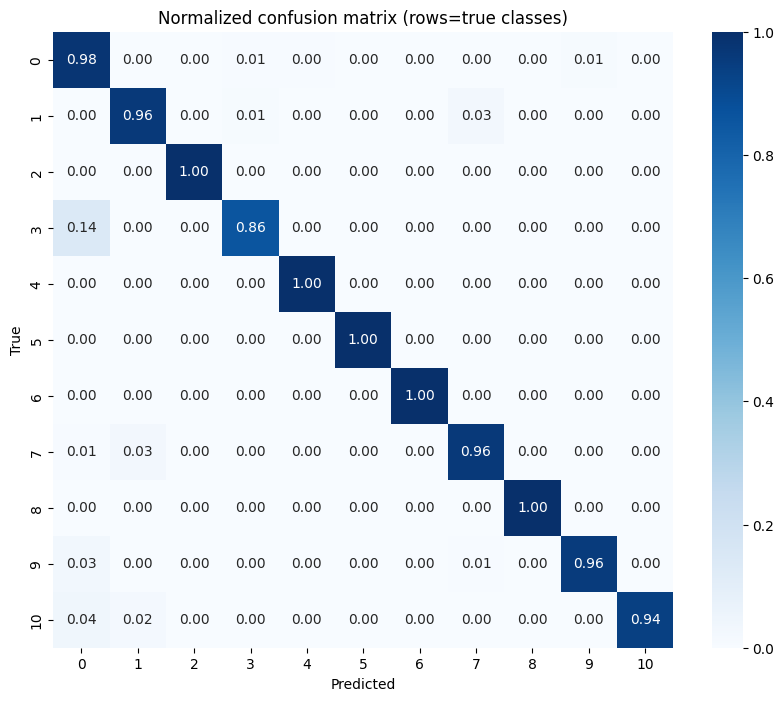

In [44]:
# Visualizing SVM Confusion Matrix
plot_confusion_matrix(y_test, svm_pred)

In [26]:
#Tuning hyperparameters of Random Forest model with GridSearch (small grids)
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 15],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_scaled, y_train)
best_rf = grid_rf.best_estimator_

# Displaying best Random Forest parameters results
print("Best RF params:", grid_rf.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best RF params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [27]:
# Tuning hyperparameters of SVM model with GridSearchCV
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42, class_weight='balanced'),
    param_grid_svm,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train_scaled, y_train)
best_svm = grid_svm.best_estimator_

# Displaying best SVM parameters results
print("Best SVM params:", grid_svm.best_params_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best SVM params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


### Comparison of models' results


In [28]:
# Predicting with a voting classifier emsemble of the base model + the two advance models
voting_model = VotingClassifier(
    estimators=[
        ("lr", grid_lr.best_estimator_),
        ("rf", best_rf),
        ("svm", best_svm)
    ],
    voting="soft"
)

voting_model.fit(X_train_scaled, y_train)
voting_pred = voting_model.predict(X_test_scaled)
voting_proba = voting_model.predict_proba(X_test_scaled)

# Displaying Voting Ensemble performance
print("\n--- Voting Ensemble Performance ---")
print(classification_report(y_test, voting_pred))
print("Accuracy:", accuracy_score(y_test, voting_pred))
print("F1-score:", f1_score(y_test, voting_pred, average='weighted'))
print("ROC-AUC:", roc_auc_score(y_test, voting_proba, multi_class='ovr'))


--- Voting Ensemble Performance ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1550
           1       0.93      0.93      0.93       107
           2       1.00      1.00      1.00       829
           3       1.00      0.86      0.92         7
           4       1.00      0.83      0.91         6
           5       1.00      1.00      1.00       400
           6       1.00      1.00      1.00       200
           7       0.98      0.98      0.98       518
           8       1.00      1.00      1.00       402
           9       0.99      0.97      0.98      1622
          10       1.00      0.98      0.99        51

    accuracy                           0.99      5692
   macro avg       0.99      0.96      0.97      5692
weighted avg       0.99      0.99      0.99      5692

Accuracy: 0.9859451862262825
F1-score: 0.9859420250827453
ROC-AUC: 0.9997636632225855


<Figure size 1000x600 with 0 Axes>

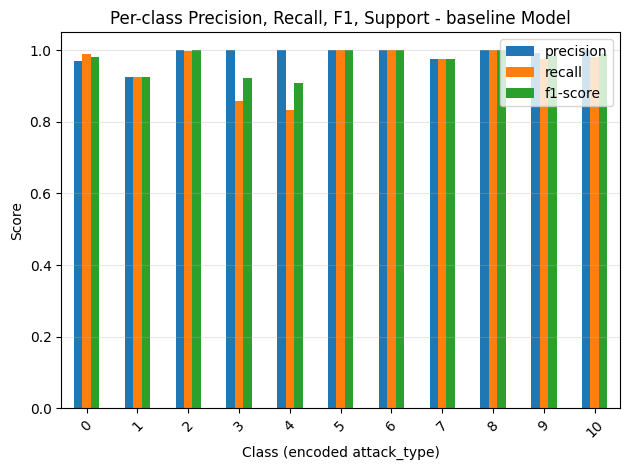

In [54]:
#Visualizing Precision, Recall, F1 per class for Voting Ensemble model
voting_report = classification_report(y_test, voting_pred, output_dict=True)
voting_report_df = pd.DataFrame(voting_report).transpose()
visualize_class_metrics(voting_report_df)

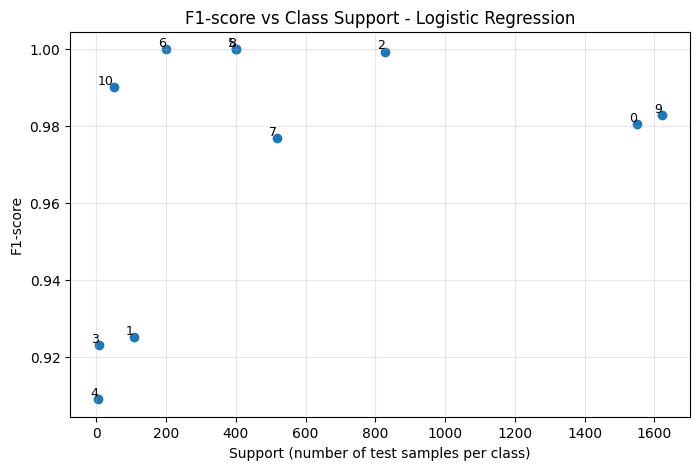

In [59]:
#visualizing F1-score vs Support per class for Voting Ensemble model
visualize_f1_vs_support(voting_report_df)

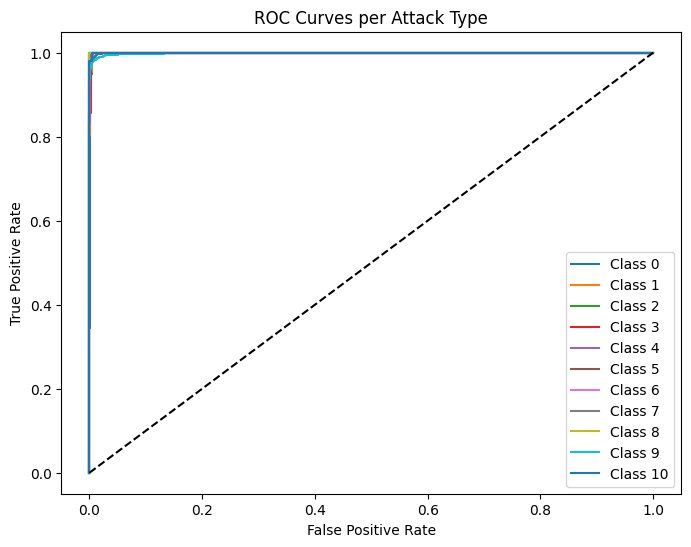

In [49]:
# Visualizing ROC curve for each class in Voting Ensemble model
plot_roc_curves(y_test, voting_proba)

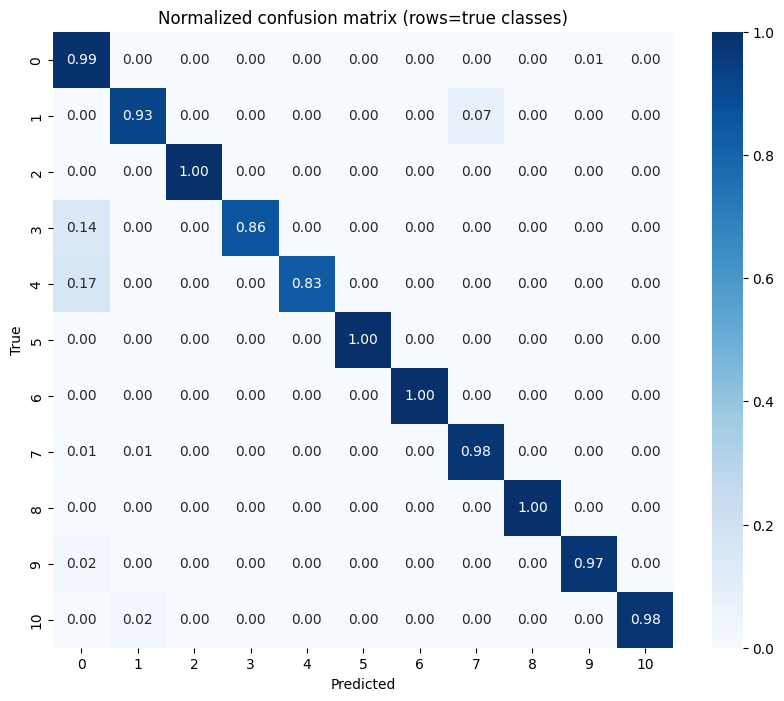

In [45]:
# Visualizing Voting Ensemble Confusion Matrix
plot_confusion_matrix(y_test, voting_pred)

### Results comparison of voting model

### visualization of model results

In [29]:
model_results = {}

# function to compute and store model results
def store_results(name, model, X, y_true):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)

    model_results[name] = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1_score": f1_score(y_true, y_pred, average='weighted'),
        "ROC-AUC": roc_auc_score(y_true, y_proba, multi_class='ovr')
    }

# Store performances
store_results("Logistic Regression", grid_lr.best_estimator_, X_test_scaled, y_test)
store_results("Random Forest", best_rf, X_test_scaled, y_test)
store_results("SVM", best_svm, X_test_scaled, y_test)
store_results("Voting Ensemble", voting_model, X_test_scaled, y_test)

model_results

# results converted to table form
results_df = pd.DataFrame(model_results).T

#displaying results table
results_df

,Accuracy,F1_score,ROC-AUC
Logistic Regression,0.957309,0.957194,0.997082
Random Forest,0.992621,0.992607,0.992159
SVM,0.976458,0.977515,0.998388
Voting Ensemble,0.985945,0.985942,0.999764


C:\Users\brhig\AppData\Local\Temp\ipykernel_27912\1137337604.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Metrics")


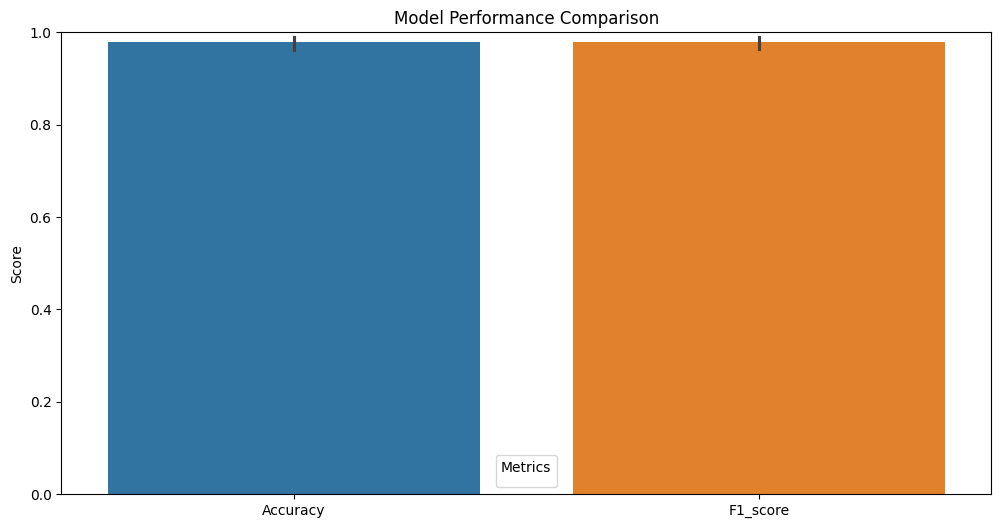

In [30]:
#visualizing Accuracy and F1-score comparison
plt.figure(figsize=(12,6))
sns.barplot(data=results_df.iloc[:, :2])
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Metrics")
plt.show()

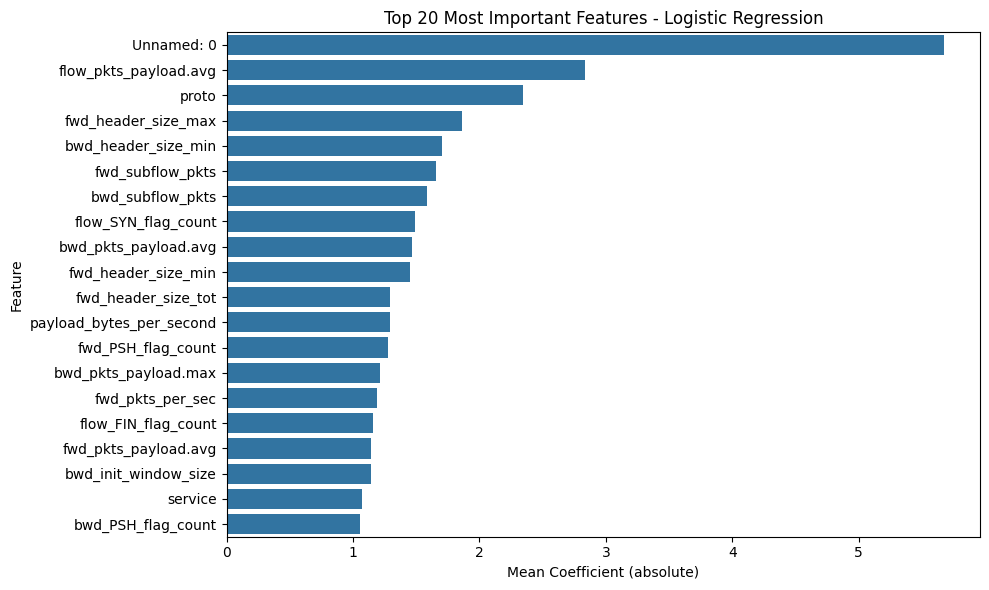

In [62]:
coefs = np.abs(baseline_model.coef_)
mean_importance = np.mean(coefs, axis=0)

#Visualizing Feature Importances for the top 20 features for baseline model
fi_lr_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': mean_importance
}).sort_values(by="Importance", ascending=False).head(20)

# Visualization
plt.figure(figsize=(10,6))
sns.barplot(data=fi_lr_df, x="Importance", y="Feature")
plt.title("Top 20 Most Important Features - Logistic Regression")
plt.xlabel("Mean Coefficient (absolute)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

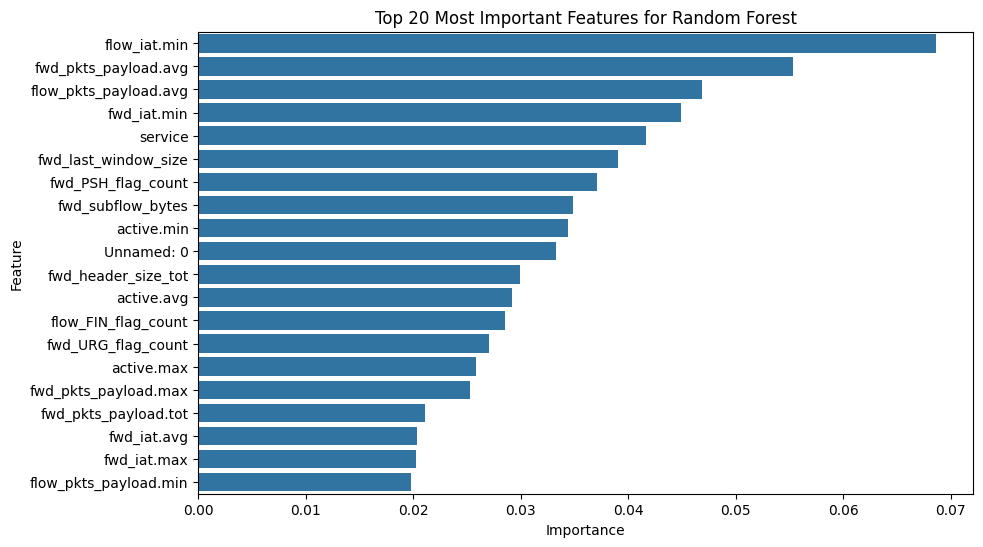

In [31]:
# Retrieving feature importance for Random Forest model
importances = best_rf.feature_importances_
features = X.columns

# converting the importances into a DataFrame for better visualization
fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by="Importance", ascending=False).head(20)

# Visualizing top 20 feature importances
plt.figure(figsize=(10,6))
sns.barplot(data=fi_df, x="Importance", y="Feature")
plt.title("Top 20 Most Important Features for Random Forest")
plt.show()

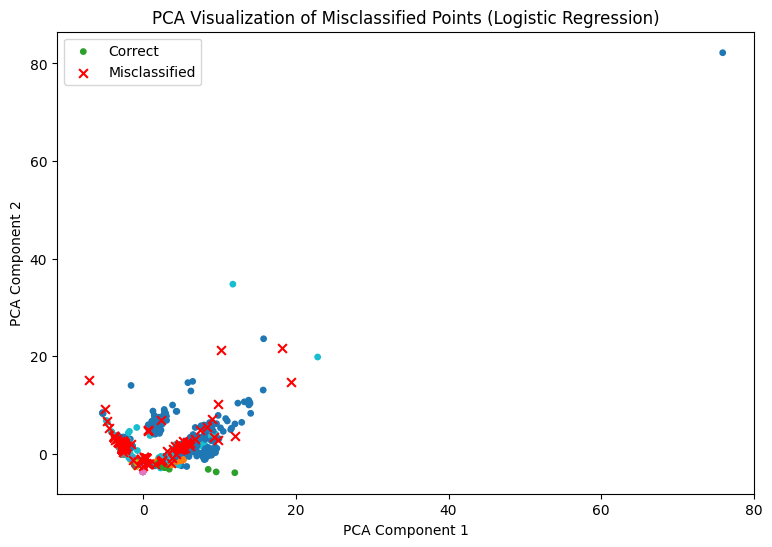

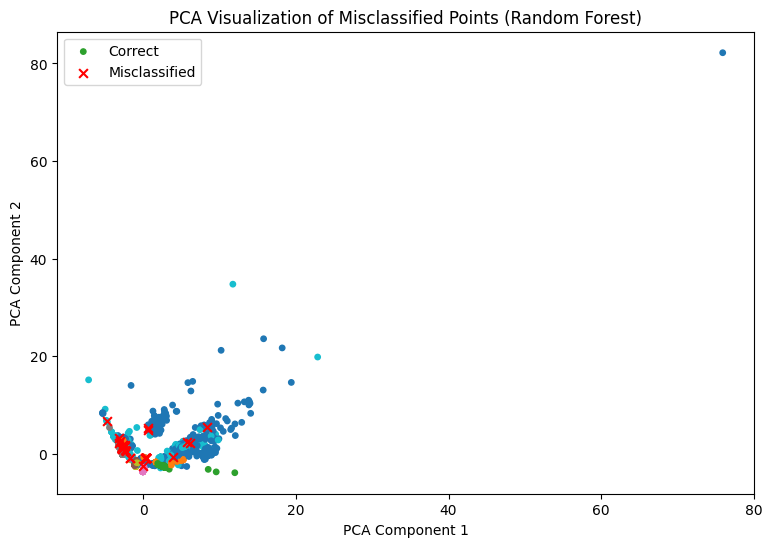

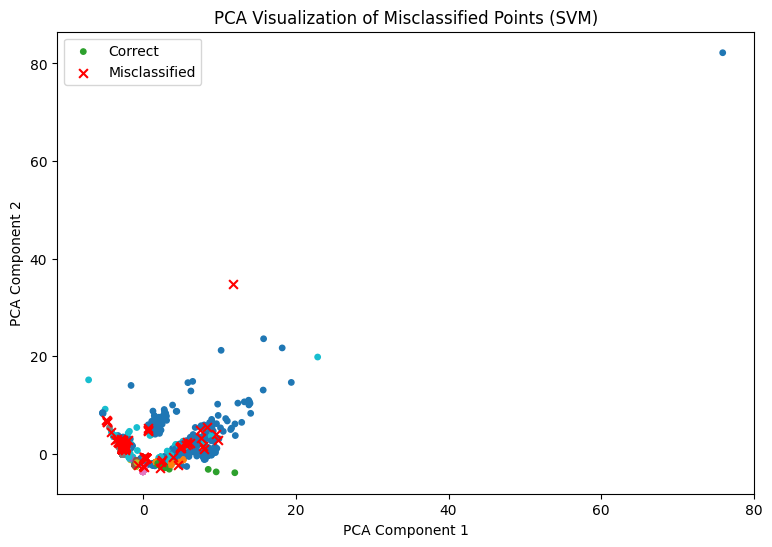

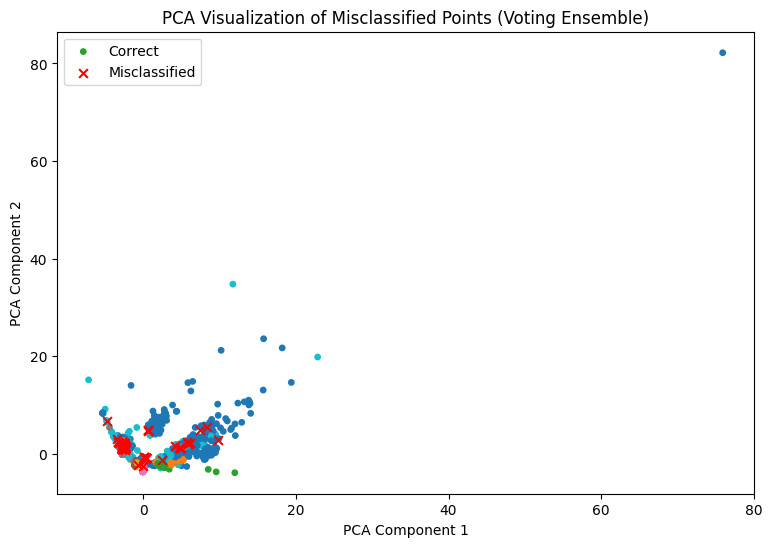

In [32]:
#PCA Misclassification visualization of all models
# Fit PCA on scaled training data
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# function to plot model's misclassifications dynamically
def plot_misclassifications(model, name):
    y_pred = model.predict(X_test_scaled)

    misclassified = y_pred != y_test

    plt.figure(figsize=(9,6))
    plt.scatter(X_test_pca[~misclassified, 0],
                X_test_pca[~misclassified, 1],
                c=y_test[~misclassified], cmap='tab10', s=15, label="Correct")

    plt.scatter(X_test_pca[misclassified, 0],
                X_test_pca[misclassified, 1],
                c='red', marker='x', s=40, label="Misclassified")

    plt.title(f"PCA Visualization of Misclassified Points ({name})")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.legend()
    plt.show()

# plot misclassification for all selected models
plot_misclassifications(grid_lr.best_estimator_, "Logistic Regression")
plot_misclassifications(best_rf, "Random Forest")
plot_misclassifications(best_svm, "SVM")
plot_misclassifications(voting_model, "Voting Ensemble")

# Conclusion
